# Partie 5 - Vision Vidéo
## Smart Urban Vision - Sup de Vinci M2

**Responsable :** Personne C (Colin)  
**Objectif :** Traiter une vidéo urbaine frame par frame avec YOLO11 et produire une vidéo annotée avec affichage des FPS.

**Livrables produits par ce notebook :**
- `outputs/video/annotated_video.mp4`
- `outputs/video/webcam_screenshot.png` (capture de démo)

> Exécuter sur **Google Colab** avec le GPU T4 activé.  
> Menu : Exécution > Modifier le type d'exécution > GPU

## Cellule 0 - Vérification GPU et montage Drive

In [1]:
# Vérification que le GPU est bien activé
import torch
print('GPU disponible :', torch.cuda.is_available())
print('Device :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU uniquement')

# Si False : Exécution > Modifier le type d'exécution > T4 GPU

GPU disponible : True
Device : Tesla T4


In [2]:
# Montage Google Drive pour sauvegarder les vidéos générées
# Les vidéos disparaissent si la session Colab expire, le Drive les conserve
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_OUTPUT = '/content/drive/MyDrive/Smart-Urban-Vision-Assets/videos'
os.makedirs(DRIVE_OUTPUT, exist_ok=True)
print('Dossier Drive prêt :', DRIVE_OUTPUT)

Mounted at /content/drive
Dossier Drive prêt : /content/drive/MyDrive/Smart-Urban-Vision-Assets/videos


## Cellule 1 - Installation des dépendances

In [3]:
# Installation ultralytics et yt-dlp
# yt-dlp permet de télécharger des vidéos YouTube libres de droits
!pip install ultralytics yt-dlp -q

# Vérification
from ultralytics import YOLO
import cv2
print('ultralytics OK :', YOLO.__module__)
print('OpenCV version :', cv2.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 87.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics OK : ultralytics.models.yolo.model
OpenCV version : 4.13.0


## Cellule 2 - Téléchargement de la vidéo urbaine

In [4]:
import os

# Création de la structure de dossiers du projet
os.makedirs('data/videos', exist_ok=True)
os.makedirs('outputs/video', exist_ok=True)

# Vidéo choisie : plan large d'une rue animée, libre de droits
# Source : YouTube, contenu libre / Creative Commons
# Durée complète coupée à 30 secondes max pour garder un fichier léger
VIDEO_URL = 'https://www.youtube.com/watch?v=MNn9qKG2UFI'
VIDEO_RAW  = 'data/videos/urban_raw.mp4'
VIDEO_CLIP = 'data/videos/urban_sample.mp4'

print('Téléchargement de la vidéo...')
!yt-dlp -f 'bestvideo[ext=mp4][height<=720]+bestaudio[ext=m4a]/best[ext=mp4][height<=720]' \
    --merge-output-format mp4 \
    -o '{VIDEO_RAW}' \
    '{VIDEO_URL}'

# Découpe des 30 premières secondes avec ffmpeg (inclus dans Colab)
print('Découpe à 30 secondes...')
!ffmpeg -y -i {VIDEO_RAW} -t 30 -c copy {VIDEO_CLIP} -loglevel quiet

# Vérification
if os.path.exists(VIDEO_CLIP):
    size_mb = os.path.getsize(VIDEO_CLIP) / 1024 / 1024
    print(f'Vidéo prête : {VIDEO_CLIP} ({size_mb:.1f} MB)')
else:
    print('ERREUR : vidéo non générée, vérifier l URL')

Téléchargement de la vidéo...
[youtube] Extracting URL: https://www.youtube.com/watch?v=MNn9qKG2UFI
[youtube] MNn9qKG2UFI: Downloading webpage
[youtube] MNn9qKG2UFI: Downloading android vr player API JSON
[info] MNn9qKG2UFI: Downloading 1 format(s): 136+140
[download] Destination: data/videos/urban_raw.f136.mp4
[download] 100% of   82.31MiB in 00:00:01 at 53.24MiB/s
[download] Destination: data/videos/urban_raw.f140.m4a
[download] 100% of    4.73MiB in 00:00:00 at 51.19MiB/s
[Merger] Merging formats into "data/videos/urban_raw.mp4"
Deleting original file data/videos/urban_raw.f136.mp4 (pass -k to keep)
Deleting original file data/videos/urban_raw.f140.m4a (pass -k to keep)
Découpe à 30 secondes...
Vidéo prête : data/videos/urban_sample.mp4 (8.8 MB)


In [5]:
# Inspection de la vidéo téléchargée
import cv2

cap = cv2.VideoCapture(VIDEO_CLIP)

fps_src    = cap.get(cv2.CAP_PROP_FPS)
width      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
n_frames   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration_s = n_frames / fps_src if fps_src > 0 else 0

cap.release()

print('Résolution  :', width, 'x', height)
print('FPS source  :', fps_src)
print('Frames total:', n_frames)
print('Durée (sec) :', round(duration_s, 1))

Résolution  : 1280 x 720
FPS source  : 30.0
Frames total: 901
Durée (sec) : 30.0


## Cellule 3 - Chargement du modèle YOLO11

In [6]:
from ultralytics import YOLO

# yolo11n.pt = version nano, équilibre vitesse / précision
# Les poids se téléchargent automatiquement au premier appel
model = YOLO('yolo11n.pt')

# Classes COCO pertinentes pour une scène urbaine
# On filtre pour éviter les détections non pertinentes (brosse à dents, etc.)
URBAN_CLASSES = [
    0,   # person
    1,   # bicycle
    2,   # car
    3,   # motorbike
    5,   # bus
    7,   # truck
    9,   # traffic light
    11,  # stop sign
    13,  # bench
    24,  # backpack
    25,  # umbrella
    26,  # handbag
    56,  # chair
    60,  # dining table
    62,  # tv
    63,  # laptop
    67,  # cell phone
    72,  # bottle
    73,  # wine glass
]

print('Modèle chargé :', model.info()[:1])
print('Nombre de classes COCO :', len(model.names))
print('Classes urbaines filtrées :', len(URBAN_CLASSES))

YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs
Modèle chargé : (181,)
Nombre de classes COCO : 80
Classes urbaines filtrées : 19


## Cellule 4 - Test rapide sur une frame

Objets détectés sur la frame test : 8
  car : 0.86
  car : 0.83
  car : 0.74
  car : 0.69
  car : 0.62
  car : 0.59
  car : 0.53
  car : 0.46


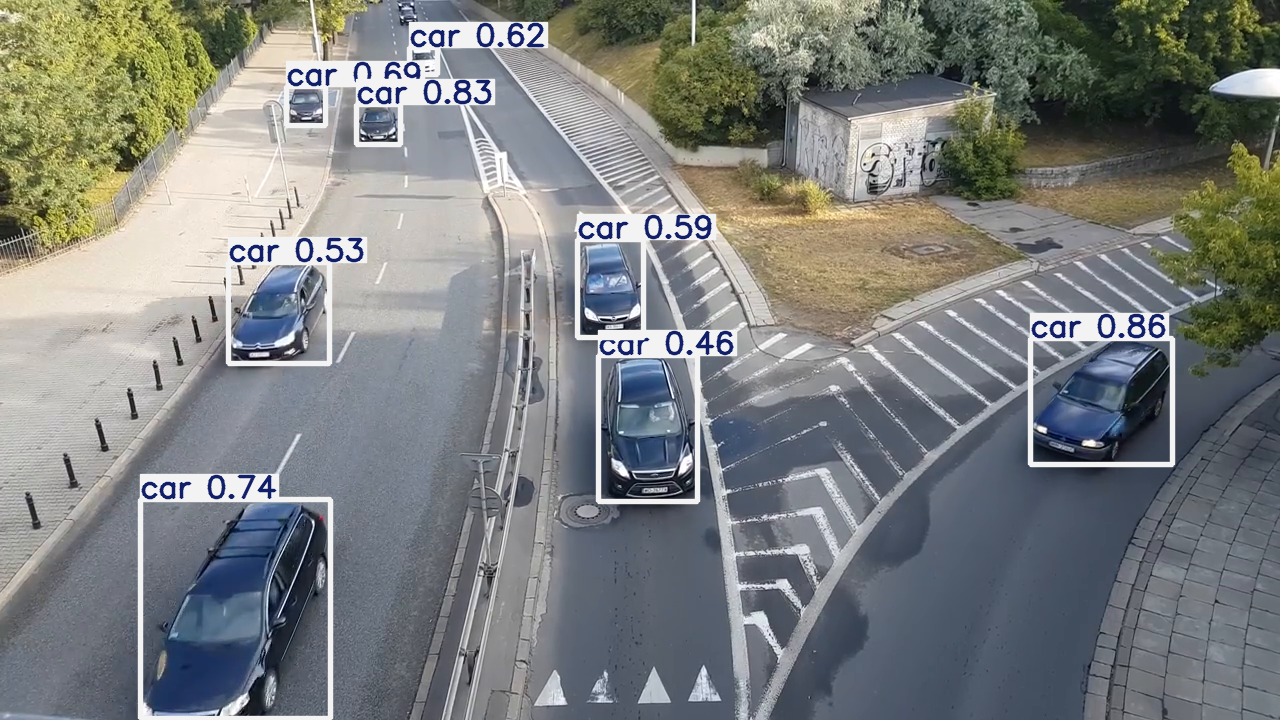

In [7]:
# Test sur une frame extraite avant de lancer le pipeline complet
# Cela permet de vérifier que les détections sont cohérentes
import cv2
import numpy as np
from google.colab.patches import cv2_imshow  # cv2.imshow ne marche pas sur Colab

cap = cv2.VideoCapture(VIDEO_CLIP)

# Extraction de la frame n°50 (évite les premières frames parfois floues)
cap.set(cv2.CAP_PROP_POS_FRAMES, 50)
ret, frame = cap.read()
cap.release()

if not ret:
    print('ERREUR : impossible de lire la frame 50')
else:
    results = model.predict(
        frame,
        conf=0.4,
        classes=URBAN_CLASSES,
        verbose=False
    )

    annotated = results[0].plot()
    print('Objets détectés sur la frame test :', len(results[0].boxes))
    for box in results[0].boxes:
        cls_id   = int(box.cls)
        cls_name = model.names[cls_id]
        conf     = float(box.conf)
        print(f'  {cls_name} : {conf:.2f}')

    # Affichage dans Colab
    cv2_imshow(annotated)

## Cellule 5 - Pipeline vidéo complet avec FPS

In [8]:
import cv2
import time
import numpy as np

VIDEO_OUT = 'outputs/video/annotated_video.mp4'

cap = cv2.VideoCapture(VIDEO_CLIP)
fps_src = cap.get(cv2.CAP_PROP_FPS)
width   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    VIDEO_OUT,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps_src,
    (width, height)
)

frame_count  = 0
fps_values   = []
total_dets   = 0

print(f'Traitement de {total} frames...')
print('Résolution :', width, 'x', height, '| FPS source :', fps_src)
print()

while cap.isOpened():
    t_start = time.time()

    ret, frame = cap.read()
    if not ret:
        break

    # Inférence YOLO sur la frame
    results = model.predict(
        frame,
        conf=0.4,
        classes=URBAN_CLASSES,
        verbose=False
    )

    annotated   = results[0].plot()
    n_dets      = len(results[0].boxes)
    total_dets += n_dets

    # Calcul des FPS réels
    elapsed = time.time() - t_start
    fps_cur = 1.0 / (elapsed + 1e-6)
    fps_values.append(fps_cur)

    # Affichage FPS en haut à gauche (texte blanc sur fond noir)
    label = f'FPS: {fps_cur:.1f}  |  Objets: {n_dets}'
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    cv2.rectangle(annotated, (8, 8), (tw + 16, th + 20), (0, 0, 0), -1)
    cv2.putText(annotated, label, (12, th + 14),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    out.write(annotated)
    frame_count += 1

    # Progression toutes les 50 frames
    if frame_count % 50 == 0:
        pct = frame_count / total * 100
        print(f'  [{pct:5.1f}%] Frame {frame_count}/{total} | FPS moy: {np.mean(fps_values[-50:]):.1f}')

cap.release()
out.release()

fps_mean = float(np.mean(fps_values))
fps_min  = float(np.min(fps_values))
fps_max  = float(np.max(fps_values))

print()
print('=' * 45)
print(f'Frames traitées   : {frame_count}')
print(f'FPS moyen         : {fps_mean:.1f}')
print(f'FPS min / max     : {fps_min:.1f} / {fps_max:.1f}')
print(f'Détections totales: {total_dets}')
print(f'Vidéo sauvegardée : {VIDEO_OUT}')
print('=' * 45)

Traitement de 901 frames...
Résolution : 1280 x 720 | FPS source : 30.0

  [  5.5%] Frame 50/901 | FPS moy: 52.3
  [ 11.1%] Frame 100/901 | FPS moy: 53.9
  [ 16.6%] Frame 150/901 | FPS moy: 55.4
  [ 22.2%] Frame 200/901 | FPS moy: 55.1
  [ 27.7%] Frame 250/901 | FPS moy: 48.3
  [ 33.3%] Frame 300/901 | FPS moy: 33.6
  [ 38.8%] Frame 350/901 | FPS moy: 42.9
  [ 44.4%] Frame 400/901 | FPS moy: 55.0
  [ 49.9%] Frame 450/901 | FPS moy: 55.5
  [ 55.5%] Frame 500/901 | FPS moy: 58.5
  [ 61.0%] Frame 550/901 | FPS moy: 55.4
  [ 66.6%] Frame 600/901 | FPS moy: 54.2
  [ 72.1%] Frame 650/901 | FPS moy: 52.9
  [ 77.7%] Frame 700/901 | FPS moy: 54.6
  [ 83.2%] Frame 750/901 | FPS moy: 40.6
  [ 88.8%] Frame 800/901 | FPS moy: 36.5
  [ 94.3%] Frame 850/901 | FPS moy: 43.9
  [ 99.9%] Frame 900/901 | FPS moy: 49.4

Frames traitées   : 901
FPS moyen         : 49.9
FPS min / max     : 17.6 / 66.0
Détections totales: 6947
Vidéo sauvegardée : outputs/video/annotated_video.mp4


## Cellule 6 - Vérification et capture d'écran de démo

Capture sauvegardée : outputs/video/webcam_screenshot.png
Frames dans la vidéo de sortie : 901


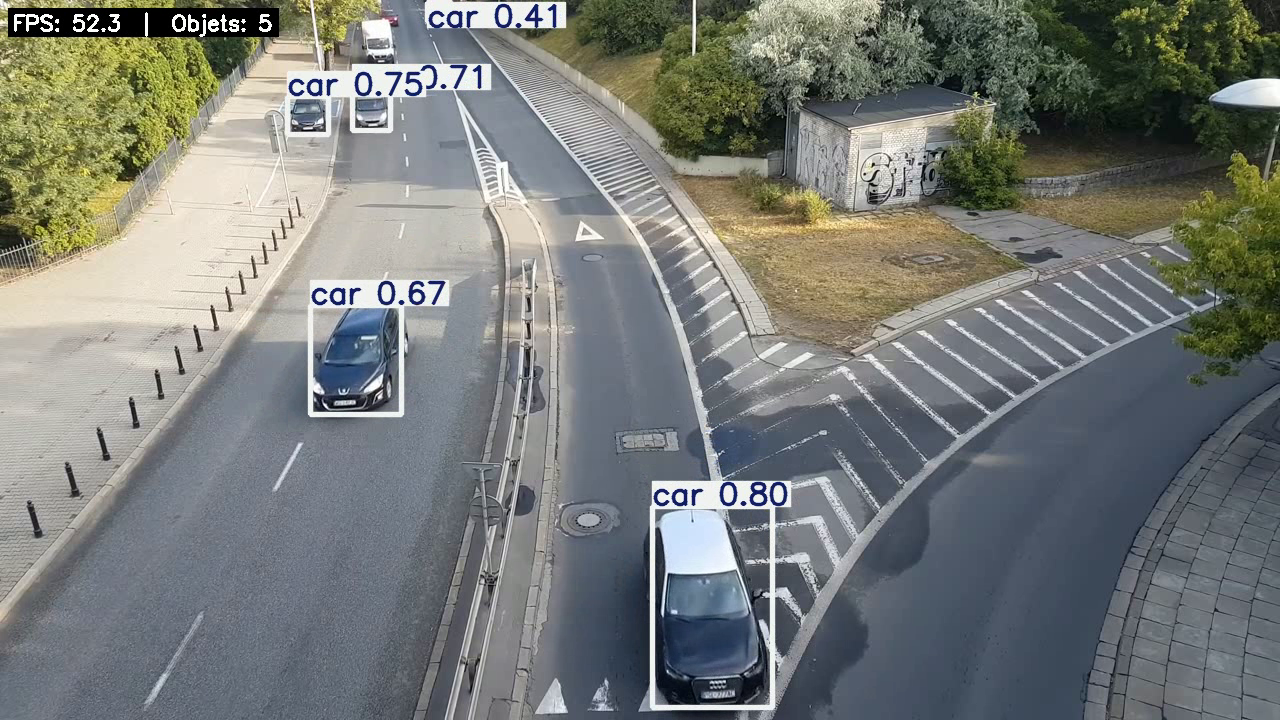

In [9]:
# Lecture de la vidéo générée pour vérifier qu'elle est bien lisible
# On extrait une frame au milieu et on l'affiche comme capture de démo
import cv2
from google.colab.patches import cv2_imshow

cap_check = cv2.VideoCapture(VIDEO_OUT)
n_out     = int(cap_check.get(cv2.CAP_PROP_FRAME_COUNT))

if n_out == 0:
    print('ERREUR : la vidéo de sortie est vide')
else:
    # Frame du milieu de la vidéo
    cap_check.set(cv2.CAP_PROP_POS_FRAMES, n_out // 2)
    ret, frame_demo = cap_check.read()
    cap_check.release()

    if ret:
        # Sauvegarde de la capture
        SCREENSHOT = 'outputs/video/webcam_screenshot.png'
        cv2.imwrite(SCREENSHOT, frame_demo)
        print(f'Capture sauvegardée : {SCREENSHOT}')
        print(f'Frames dans la vidéo de sortie : {n_out}')
        cv2_imshow(frame_demo)
    else:
        print('ERREUR : impossible de lire la frame de vérification')

## Cellule 7 - Commentaires sur la fluidité et les limites

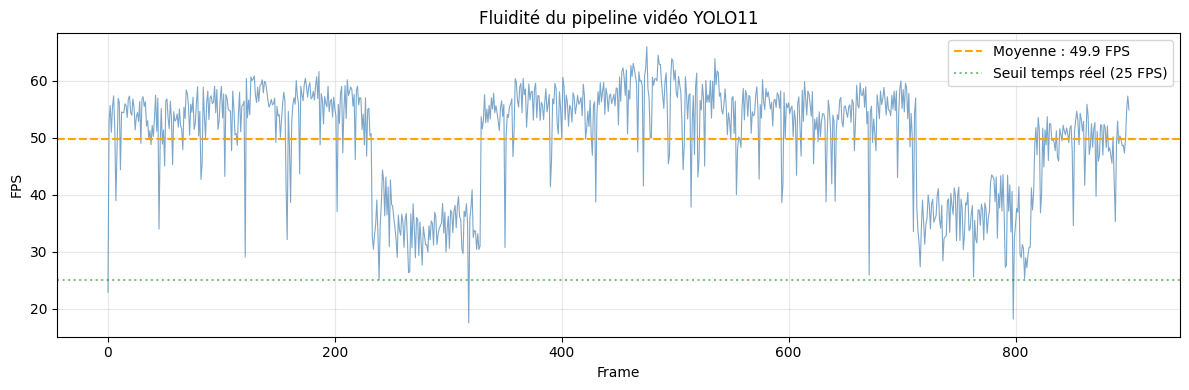

Courbe FPS sauvegardée.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Visualisation de la courbe FPS frame par frame
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fps_values, color='steelblue', alpha=0.7, linewidth=0.8)
ax.axhline(fps_mean, color='orange', linestyle='--', label=f'Moyenne : {fps_mean:.1f} FPS')
ax.axhline(25, color='green', linestyle=':', alpha=0.5, label='Seuil temps réel (25 FPS)')
ax.set_xlabel('Frame')
ax.set_ylabel('FPS')
ax.set_title('Fluidité du pipeline vidéo YOLO11')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/video/fps_curve.png', dpi=100)
plt.show()
print('Courbe FPS sauvegardée.')

In [11]:
# Analyse des limites observées
print('ANALYSE DES PERFORMANCES')
print('=' * 45)
print(f'FPS moyen       : {fps_mean:.1f}')
print(f'Temps réel (25) : {"ATTEINT" if fps_mean >= 25 else "NON ATTEINT"}')
print()
print('LIMITES IDENTIFIEES :')
print()
print('1. Faux positifs : YOLO peut détecter des objets à faible confiance')
print('   sur des zones floues ou aux bords de frame.')
print('   Mitigation : seuil de confiance à 0.4, filtre sur classes urbaines.')
print()
print('2. Eclairage : performances dégradées sur scènes nocturnes')
print('   ou en contre-jour (surexposition).')
print()
print('3. Angle de vue : modèle entraîné sur vues piétonnes standards.')
print('   Vue drone ou angle de caméra atypique réduit la précision.')
print()
print('4. Fluidité : sur CPU, le pipeline descend sous 10 FPS.')
print('   Nécessite un GPU pour un usage temps réel.')
print('=' * 45)

ANALYSE DES PERFORMANCES
FPS moyen       : 49.9
Temps réel (25) : ATTEINT

LIMITES IDENTIFIEES :

1. Faux positifs : YOLO peut détecter des objets à faible confiance
   sur des zones floues ou aux bords de frame.
   Mitigation : seuil de confiance à 0.4, filtre sur classes urbaines.

2. Eclairage : performances dégradées sur scènes nocturnes
   ou en contre-jour (surexposition).

3. Angle de vue : modèle entraîné sur vues piétonnes standards.
   Vue drone ou angle de caméra atypique réduit la précision.

4. Fluidité : sur CPU, le pipeline descend sous 10 FPS.
   Nécessite un GPU pour un usage temps réel.


## Cellule 8 - Sauvegarde sur Google Drive

In [12]:
import shutil

# Copie de la vidéo annotée sur Drive
# La session Colab s'efface, le Drive conserve les fichiers
shutil.copy(VIDEO_OUT, DRIVE_OUTPUT + '/annotated_video.mp4')
shutil.copy('outputs/video/webcam_screenshot.png',
            DRIVE_OUTPUT + '/webcam_screenshot.png')

print('Fichiers copiés sur Google Drive :')
print(' ', DRIVE_OUTPUT + '/annotated_video.mp4')
print(' ', DRIVE_OUTPUT + '/webcam_screenshot.png')
print()
print('Partager ce dossier Drive avec l equipe pour que D')
print('puisse mettre à jour le lien dans le README.')

Fichiers copiés sur Google Drive :
  /content/drive/MyDrive/Smart-Urban-Vision-Assets/videos/annotated_video.mp4
  /content/drive/MyDrive/Smart-Urban-Vision-Assets/videos/webcam_screenshot.png

Partager ce dossier Drive avec l equipe pour que D
puisse mettre à jour le lien dans le README.
